EDA (EXPLORATORY DATA ANALYSIS) ON  GOOGLE STOCK MARKET DATA

In [371]:
#Importing Necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [372]:
df=pd.read_csv(r"C:\DataScience\google_stock_data.csv")
df.head(5)

,Price,Close,High,Low,Open,Volume
0,Ticker,GOOGL,GOOGL,GOOGL,GOOGL,GOOGL
1,Date,NaN,NaN,NaN,NaN,NaN
2,2025-03-10,165.41319274902344,167.99607150995365,163.23920372577845,167.7966101322015,43604000
3,2025-03-11,163.58824157714844,166.29078517095678,160.9255963482493,164.4558560210946,39587400
4,2025-03-12,166.6497802734375,167.17831943801426,163.07963775446962,166.12124110886077,28372400


CLEANING THE DATASET

In [373]:
#1.convert the column names to a standard type 
#2.check the shape of dataset 
#3.take information of the  dataset
#4.take a statistical summary of a dataset 
#5.describe the dataset 
#6.find missing values in the dataset 
#7.if missing values are present, handle it using filna()or dropna () based on your assumptions
#8.check for duplicates values,if present handle it
#9.check wheteher the date column is in correct format, if not convert date format
#10.drop columns which is not at all necessary


In [374]:
df=df.iloc[3:]#Removes First 3 Rows

In [375]:
df.rename(columns={'Price':'Date'}, inplace=True)#Rename "Price" to "Date"

In [376]:
#Convert Data Types
df['Date'] = pd.to_datetime(df['Date'])

df[['Close','High','Low','Open']] = df[['Close','High','Low','Open']].astype(float)

df['Volume'] = df['Volume'].astype(int)

In [377]:
#1.convert the column names to a standard type 
df.columns=df.columns.str.replace(' ','_').str.title()
df.columns=df.columns.str.replace('-','_')
df.head(3)


,Date,Close,High,Low,Open,Volume
3,2025-03-11,163.588242,166.290785,160.925596,164.455856,39587400
4,2025-03-12,166.649780,167.178319,163.079638,166.121241,28372400
5,2025-03-13,162.311752,165.672482,161.663549,165.582718,31756200


In [378]:
#2.check the shape of dataset 
df.shape

(249, 6)

In [379]:
#3.take information of the  dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 3 to 251
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    249 non-null    datetime64[ns]
 1   Close   249 non-null    float64       
 2   High    249 non-null    float64       
 3   Low     249 non-null    float64       
 4   Open    249 non-null    float64       
 5   Volume  249 non-null    int32         
dtypes: datetime64[ns](1), float64(4), int32(1)
memory usage: 10.8 KB


In [380]:
#4.take a statistical summary of a dataset 
df.describe()

,Close,High,Low,Open,Volume
count,249.000000,249.000000,249.000000,249.000000,2.490000e+02
mean,234.299254,237.052752,231.123600,234.115918,3.739051e+07
std,64.381488,65.120772,63.547282,64.498810,1.589463e+07
min,144.301498,148.539795,140.142984,141.160179,1.009740e+07
25%,171.386703,173.939651,169.677168,171.376741,2.846410e+07
50%,234.636536,237.974347,233.077533,234.016921,3.253660e+07
75%,303.329987,306.219711,300.750000,303.040009,4.138920e+07
max,343.690002,349.000000,337.470001,347.339996,1.274901e+08


In [381]:
#5.describe the dataset 
df.describe()

,Close,High,Low,Open,Volume
count,249.000000,249.000000,249.000000,249.000000,2.490000e+02
mean,234.299254,237.052752,231.123600,234.115918,3.739051e+07
std,64.381488,65.120772,63.547282,64.498810,1.589463e+07
min,144.301498,148.539795,140.142984,141.160179,1.009740e+07
25%,171.386703,173.939651,169.677168,171.376741,2.846410e+07
50%,234.636536,237.974347,233.077533,234.016921,3.253660e+07
75%,303.329987,306.219711,300.750000,303.040009,4.138920e+07
max,343.690002,349.000000,337.470001,347.339996,1.274901e+08


In [382]:
#6.find missing values in the dataset 
df.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [383]:
#7.check for duplicates values,if present handle it
df[df.duplicated()]
df=df.drop_duplicates()
df.duplicated().sum()


0

In [384]:
#8.check wheteher the date column is in correct format, if not convert date format
df['Date']=pd.to_datetime(df['Date'])
df['Date'].info()


<class 'pandas.core.series.Series'>
Int64Index: 249 entries, 3 to 251
Series name: Date
Non-Null Count  Dtype         
--------------  -----         
249 non-null    datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 3.9 KB


In [385]:
df['Month'] = df['Date'].dt.month 

DATA ANALYSIS AND VISUALIZATION

In [386]:
#1.How does the closing price change over time?
#2.How does trading volume change over time?
#3.What is the relationship between Open and Close price?
#4.What is the daily price range?
#5.Correlation between stock features
#6.Monthly average closing price
#7.Highest trading volume day
#8.Which day had the highest and lowest closing price?
#9.Top 5 highest trading volume days
#10.Compare Open vs Close using a line chart

Trend Analysis of Closing Prices Over Time

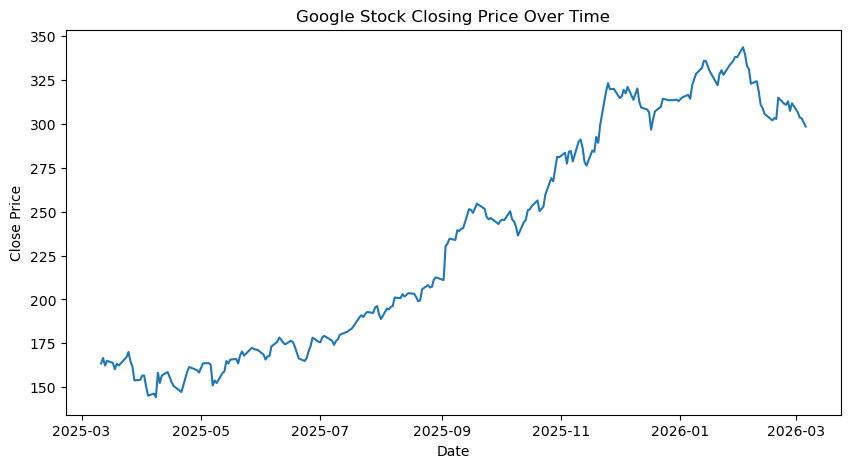

In [387]:
#1.How does the closing price change over time?
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Close'])
plt.title("Google Stock Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

Trend Analysis of Trading Volume Over Time

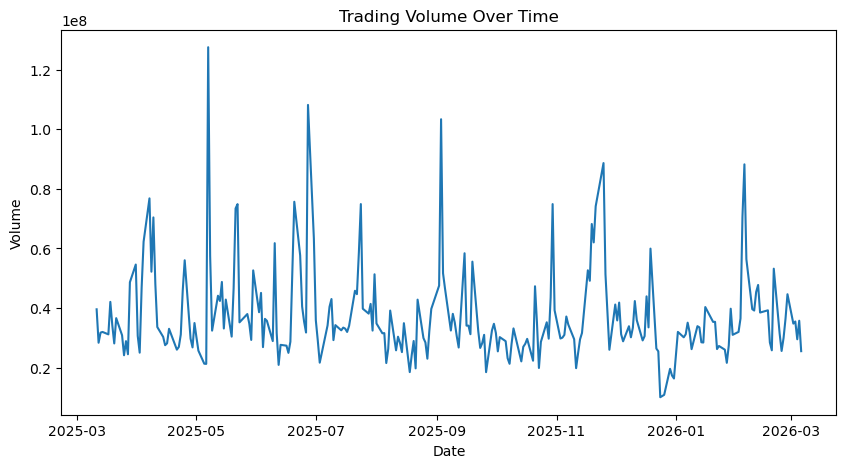

In [388]:
#2.How does trading volume change over time?
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Volume'])
plt.title("Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

- Trading volume is generally fluctuating, with no consistent upward or downward trend.
- Most of the time, volume stays within a moderate range, indicating steady trading activity.
- There are occasional sharp spikes, representing days of unusually high trading activity.
- Some brief dips also appear, showing lower participation on certain days.

Conclusion: Trading volume is mostly stable with irregular spikes, suggesting periodic surges in market activity rather than a steady trend.

Relationship Between Opening and Closing Prices

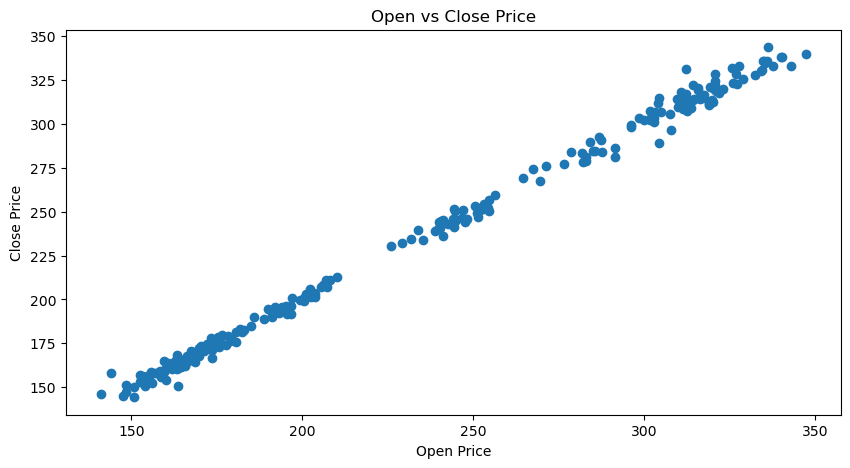

In [389]:
#3.What is the relationship between Open and Close price?
plt.figure(figsize=(10,5))
plt.scatter(df['Open'], df['Close'])
plt.xlabel("Open Price")
plt.ylabel("Close Price")
plt.title("Open vs Close Price")
plt.show()

Analysis of Daily Price Range

          Date      Range
231 2026-02-05  26.230011


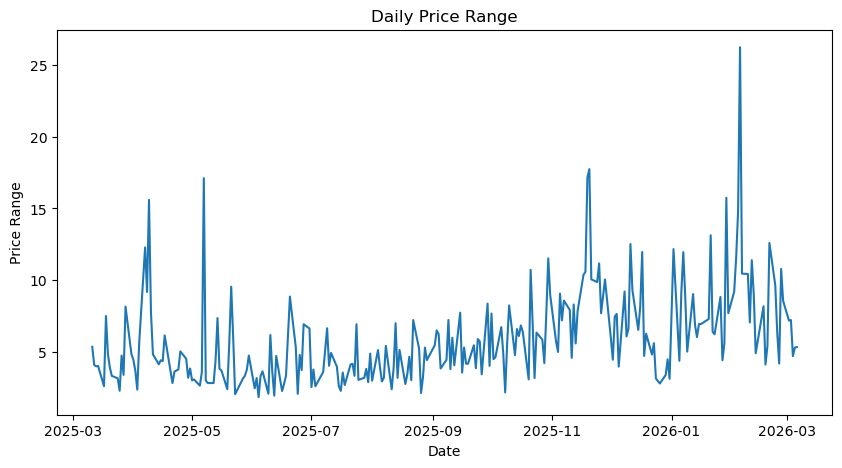

In [390]:
#4.What is the daily price range?
df['Range'] = df['High'] - df['Low']
print(df[['Date','Range']].sort_values(by='Range', ascending=False).head(1))
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Range'])
plt.title("Daily Price Range")
plt.xlabel("Date")
plt.ylabel("Price Range")
plt.show()

- Daily price range is generally low to moderate, indicating stable movement on most days.
- There are occasional sharp spikes, showing sudden periods of high volatility.
- The highest spike occurs toward the later period, marking the most volatile day.
- Volatility slightly increases over time, with more fluctuations in later months.

Conclusion: The data shows mostly stable daily movements with occasional spikes, and a slight increase in volatility toward the end.

Correlation Analysis of Stock Features

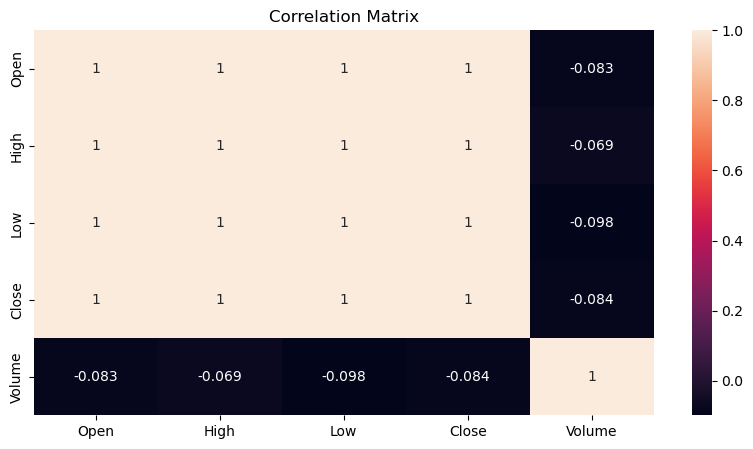

In [391]:
#5.Correlation between stock features
plt.figure(figsize=(10,5))
sns.heatmap(df[['Open','High','Low','Close','Volume']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

Average Closing Price by Month 

Month_name
January      328.869501
February     316.670524
December     312.462780
November     292.735886
October      254.004291
September    242.335175
August       201.777904
March        197.771702
July         184.647599
June         172.241089
May          163.926829
April        154.132451
Name: Close, dtype: float64


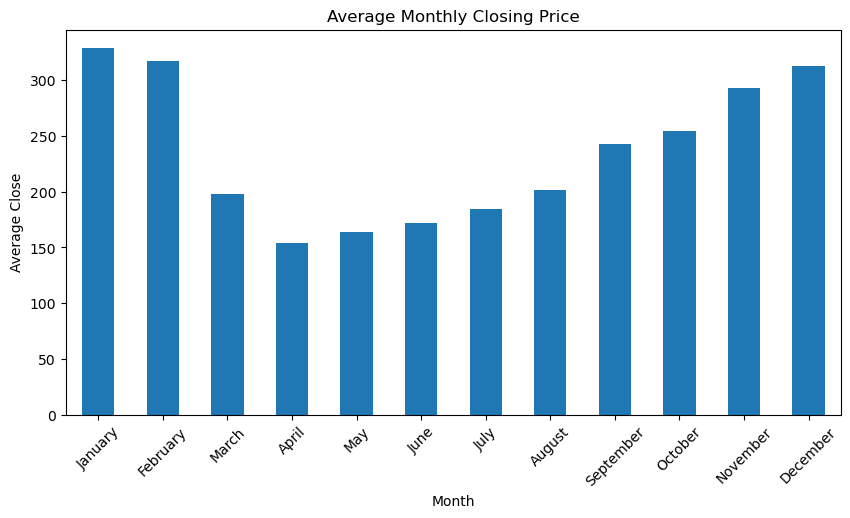

In [392]:
# Create Month column as names instead of numbers
df['Month_name'] = pd.to_datetime(df['Date']).dt.month_name()

monthly = df.groupby('Month_name')['Close'].mean()

# Keep correct calendar order
months_order = ['January','February','March','April','May','June',
                'July','August','September','October','November','December']

monthly = monthly.reindex(months_order)

print(monthly.sort_values(ascending=False))

plt.figure(figsize=(10,5))
monthly.plot(kind='bar')

plt.title("Average Monthly Closing Price")
plt.xlabel("Month")
plt.ylabel("Average Close")
plt.xticks(rotation=45)
plt.show()

- The highest average closing prices occur in January and February, indicating strong performance at the start of the year.
- Prices decline sharply and hit a low around April, marking the weakest period.
- From May onward, there is a steady upward trend, showing recovery.
- By November and December, prices are again relatively high, though slightly below the early-year peak.

Conclusion: The data shows a clear seasonal pattern — strong start, mid-year dip, and gradual recovery toward year-end.

Day with the Highest Trading Volume

In [393]:
#7.Highest trading volume day
df.loc[df['Volume'].idxmax()]
#Shows the most active trading day.

Date          2025-05-07 00:00:00
Close                  150.963104
High                    164.54559
Low                    147.432845
Open                   163.628125
Volume                  127490100
Month                           5
Range                   17.112745
Month_name                    May
Name: 43, dtype: object

Days with Highest and Lowest Closing Prices

In [394]:
#8.Which day had the highest and lowest closing price?
print("Highest closing price\n",df.loc[df['Close'].idxmax(), ['Date','Close']],"\n")
print("Lowest closing price\n",df.loc[df['Close'].idxmin(), ['Date','Close']])

Highest closing price
 Date     2026-02-02 00:00:00
Close             343.690002
Name: 228, dtype: object 

Lowest closing price
 Date     2025-04-08 00:00:00
Close             144.301498
Name: 23, dtype: object


Top 5 Days with Highest Trading Volume

Top 5 highest trading volume days
            Date     Volume
43   2025-05-07  127490100
78   2025-06-27  108140200
124  2025-09-03  103336100
183  2025-11-25   88632100
231  2026-02-05   88205800


<Figure size 1000x500 with 0 Axes>

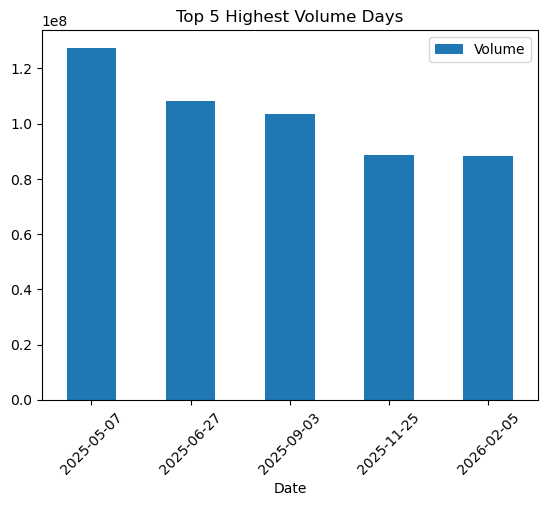

In [395]:
df['Date'] = pd.to_datetime(df['Date']).dt.date
top5 = df[['Date', 'Volume']].sort_values(by='Volume', ascending=False).head(5)
print("Top 5 highest trading volume days\n", top5)
plt.figure(figsize=(10,5))
top5.plot(x='Date', y='Volume', kind='bar')
plt.title("Top 5 Highest Volume Days")
plt.xticks(rotation=45)
plt.show()

Open and Close Price Trend Comparison 

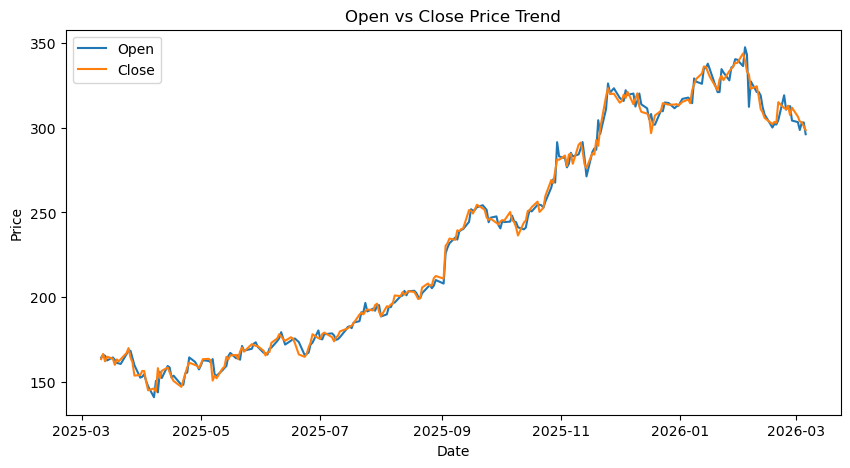

In [396]:
#10.Compare Open vs Close using a line chart
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Open'], label='Open')
plt.plot(df['Date'], df['Close'], label='Close')
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Open vs Close Price Trend")
plt.legend()
plt.show()

MULTIPLE LINEAR REGRESSION

In [397]:
mlr_x=df[['High','Low','Open','Volume','Range','Month']].values
mlr_y=df['Close'].values


In [398]:
from sklearn.model_selection import train_test_split
mlr_x_train,mlr_x_test,mlr_y_train,mlr_y_test=train_test_split(mlr_x,mlr_y,test_size=0.2,random_state=0)
from sklearn.linear_model import LinearRegression
regressor=LinearRegression()
regressor.fit(mlr_x_train,mlr_y_train)

LinearRegression()

In [399]:
mlr_y_pred=regressor.predict(mlr_x_test)

In [400]:
#evaluating the model
from sklearn import metrics
score=metrics.r2_score(mlr_y_test,mlr_y_pred)
print("R2 score:",score*100,"%")
print("RMSE:", np.sqrt(metrics.mean_squared_error(mlr_y_test,mlr_y_pred)))
print("Mean absoulute error:",metrics.mean_absolute_error(mlr_y_test,mlr_y_pred))
print("Mean squared error:",metrics.mean_squared_error(mlr_y_test,mlr_y_pred))


R2 score: 99.92627920117373 %
RMSE: 1.666285141892985
Mean absoulute error: 1.1258322062174988
Mean squared error: 2.776506174093325


POLYNOMIAL REGRESSION 

In [401]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
df.head(5)

,Date,Close,High,Low,Open,Volume,Month,Range,Month_name
3,2025-03-11,163.588242,166.290785,160.925596,164.455856,39587400,3,5.365189,March
4,2025-03-12,166.649780,167.178319,163.079638,166.121241,28372400,3,4.098682,March
5,2025-03-13,162.311752,165.672482,161.663549,165.582718,31756200,3,4.008933,March
6,2025-03-14,165.034256,166.031502,162.002619,162.820369,31995900,3,4.028883,March
7,2025-03-17,163.837555,165.842029,163.219267,164.575523,31184300,3,2.622762,March


In [402]:
pnr_x=df[['Open']].values
pnr_y=df['Close'].values


In [403]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(pnr_x)

In [404]:
from sklearn.model_selection import train_test_split

X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(
    X_poly, pnr_y, test_size=0.2, random_state=0
)

In [405]:
from sklearn.linear_model import LinearRegression

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train_poly)

LinearRegression()

In [406]:
y_poly_pred = poly_model.predict(X_test_poly)

In [407]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_poly, pnr_y)


LinearRegression()

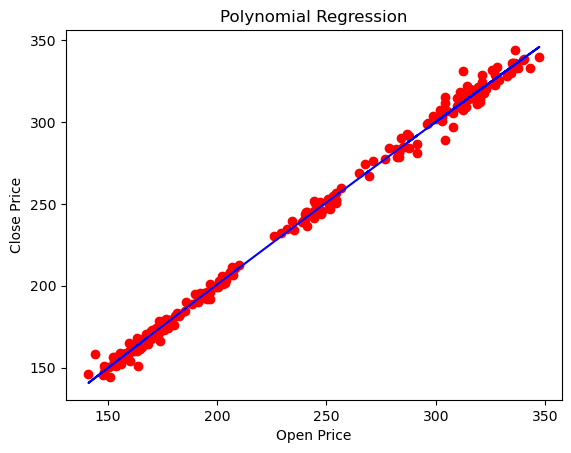

In [408]:
plt.scatter(pnr_x, pnr_y, color='red')
plt.plot(pnr_x, model.predict(X_poly), color='blue')
plt.xlabel("Open Price")
plt.ylabel("Close Price")
plt.title("Polynomial Regression")

plt.show()

CLASSIFICATION

BACKWARD ELIMINATION

In [409]:
x=df[['High','Low','Open','Volume','Range','Month']].values
y=df['Close'].values


In [410]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test,=train_test_split(x,y,test_size=0.2,random_state=0)

In [411]:
from sklearn.linear_model import LinearRegression
regressor=LinearRegression()
regressor.fit(x_train,y_train)
y_pred=regressor.predict(x_test)
print('Train score:',regressor.score(x_train,y_train))
print('Test score:',regressor.score(x_test,y_test))

Train score: 0.999399051675114
Test score: 0.9992627920117373


In [412]:
import statsmodels.api as sm
x_new=np.append(np.ones((249,1)).astype(int),x,axis=1)


In [413]:
import statsmodels.api as sm
x_opt=x_new[:,[0,1,2,3,4,5,6]].astype('float')
regressor_ols=sm.OLS(endog=y,exog=x_opt).fit()
regressor_ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 7.889e+04
Date:                Mon, 27 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:00:55   Log-Likelihood:                -469.46
No. Observations:                 249   AIC:                             950.9
Df Residuals:                     243   BIC:                             972.0
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0184      0.542      0.034      0.973      -1.049       1.086
x1             0.7409      0.026     28.401      0.000       0.690       0.792
x2             0.7330      0.027     27.375      0.000       0.680       0.786
x3            -0.4726      0.042    -11.270      0.000      -0.555      -0.390
x4         -1.609e-09   8.64e-09     -0.186      0.852   -1.86e-08    1.54e-08
x5             0.0079      0.032      0.248      0.805      -0.055       0.071
x6            -0.0164      0.030     -0.538      0.591      -0.076       0.044
==============================================================================
Omnibus:                       26.815   Durbin-Watson:                   1.864
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              134.468
Skew:                          -0.018   Prob(JB):                     6.32e-30
Kurtosis:                       6.600   Cond. No.                     1.70e+21
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 1.43e-25. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [414]:
import statsmodels.api as sm
x_opt=x_new[:,[0,1,2,3,4,5]].astype('float')
regressor_ols=sm.OLS(endog=y,exog=x_opt).fit()
regressor_ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 9.890e+04
Date:                Mon, 27 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:00:55   Log-Likelihood:                -469.60
No. Observations:                 249   AIC:                             949.2
Df Residuals:                     244   BIC:                             966.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0486      0.527     -0.092      0.927      -1.086       0.989
x1             0.7420      0.026     28.568      0.000       0.691       0.793
x2             0.7313      0.027     27.533      0.000       0.679       0.784
x3            -0.4723      0.042    -11.280      0.000      -0.555      -0.390
x4         -1.968e-09   8.61e-09     -0.229      0.819   -1.89e-08     1.5e-08
x5             0.0106      0.032      0.337      0.736      -0.052       0.073
==============================================================================
Omnibus:                       27.872   Durbin-Watson:                   1.858
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              146.782
Skew:                          -0.023   Prob(JB):                     1.34e-32
Kurtosis:                       6.761   Cond. No.                     1.69e+21
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 1.45e-25. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [415]:
import statsmodels.api as sm
x_opt=x_new[:,[0,1,2,3,4]].astype('float')
regressor_ols=sm.OLS(endog=y,exog=x_opt).fit()
regressor_ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 9.890e+04
Date:                Mon, 27 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:00:55   Log-Likelihood:                -469.60
No. Observations:                 249   AIC:                             949.2
Df Residuals:                     244   BIC:                             966.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0486      0.527     -0.092      0.927      -1.086       0.989
x1             0.7526      0.051     14.659      0.000       0.651       0.854
x2             0.7207      0.052     13.795      0.000       0.618       0.824
x3            -0.4723      0.042    -11.280      0.000      -0.555      -0.390
x4         -1.968e-09   8.61e-09     -0.229      0.819   -1.89e-08     1.5e-08
==============================================================================
Omnibus:                       27.872   Durbin-Watson:                   1.858
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              146.782
Skew:                          -0.023   Prob(JB):                     1.34e-32
Kurtosis:                       6.761   Cond. No.                     2.10e+08
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.1e+08. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [416]:
import statsmodels.api as sm
x_opt=x_new[:,[0,1,2,3]].astype('float')
regressor_ols=sm.OLS(endog=y,exog=x_opt).fit()
regressor_ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 1.324e+05
Date:                Mon, 27 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:00:55   Log-Likelihood:                -469.63
No. Observations:                 249   AIC:                             947.3
Df Residuals:                     245   BIC:                             961.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1303      0.386     -0.338      0.736      -0.891       0.630
x1             0.7457      0.041     18.098      0.000       0.664       0.827
x2             0.7280      0.041     17.666      0.000       0.647       0.809
x3            -0.4724      0.042    -11.305      0.000      -0.555      -0.390
==============================================================================
Omnibus:                       28.146   Durbin-Watson:                   1.862
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              150.238
Skew:                          -0.018   Prob(JB):                     2.38e-33
Kurtosis:                       6.805   Cond. No.                     1.59e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.59e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [417]:
x_BE=df[['High','Low','Open']]
y_BE=df['Close']

In [418]:
from sklearn.model_selection import train_test_split
x_BE_train,x_BE_test,y_BE_train,y_BE_test=train_test_split(x_BE,y_BE,test_size=0.2,random_state=0)

In [419]:
from sklearn.linear_model import LinearRegression
regressor=LinearRegression()
regressor.fit(x_BE_train,y_BE_train)
y_pred=regressor.predict(x_BE_test)

In [420]:
print('Train score:',regressor.score(x_BE_train,y_BE_train))
print('Test score:',regressor.score(x_BE_test,y_BE_test))

Train score: 0.999398314096791
Test score: 0.9992695181907514


BEST MODEL

In [421]:
scores = {
    "MultiLinear Regression": metrics.r2_score(mlr_y_test,mlr_y_pred),
    "After Backward Elimination": metrics.r2_score(y_BE_test, y_pred),
    "Polynomial Regression": metrics.r2_score(y_test_poly, y_poly_pred)
}

best_model = max(scores, key=scores.get)
print("Model Scores:\n")
for model, score in scores.items():
    print(model, ":", score)
print("Best Model:", best_model)

Model Scores:

MultiLinear Regression : 0.9992627920117373
After Backward Elimination : 0.9992695181907514
Polynomial Regression : 0.9964499440226703
Best Model: After Backward Elimination


## CONCLUSION

After performing Exploratory Data Analysis (EDA), Regression modeling, and Backward Elimination, we can summarize the key findings:
### 1. Data Understanding & Cleaning
- The dataset initially contained extra header rows (Ticker, Date) which required preprocessing.
- Columns were converted to proper data types (datetime, float, int) for analysis.
- Final dataset was structured as a time-series dataset.
### 2. Exploratory Data Analysis (EDA)
- Stock prices (Open, High, Low, Close) showed strong correlation.
- The stock exhibited daily fluctuations (volatility) measured using price range.
- Certain days showed high trading volume, indicating strong market activity.
- Overall trend helped identify bullish and bearish periods.
### 3. Linear Regression
- Built a Multiple Linear Regression model to predict Close price.
- Features used:
  - Open, High, Low, Volume.
- Model showed:
  - Strong predictive relationship.
  - Good performance based on R² and RMSE.
### 4. Polynomial Regression 
- Polynomial Regression was applied to capture non-linear patterns.
- However, the dataset showed a mostly linear relationship between variables (especially Open vs Close).
- Key Finding:
  - Polynomial Regression did NOT significantly improve the model.
- Reason:
  - Data is already linear.
  - Adding polynomial terms (x², x³) does not add useful information.
### 5. Backward Elimination
- Used p-values to remove insignificant variables.
- Eliminated features with p-value > 0.05.
- Result:
  - Reduced model complexity.
  - Improved interpretability.
  - Retained only important predictors.
### 6.Key Insights
- Open, High, Low are strong predictors of Close price.
- Volume has limited impact in prediction.
- Stock data shows:
  - High linear correlation.
  - Daily volatility.
  - Trend patterns over time.
### Final Conclusion
- EDA helped uncover patterns and relationships in the stock data.
- Linear Regression provided an effective baseline prediction model.
- Polynomial Regression did not improve performance as the data was mostly linear.
- Backward Elimination optimized the model by removing irrelevant features.